   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

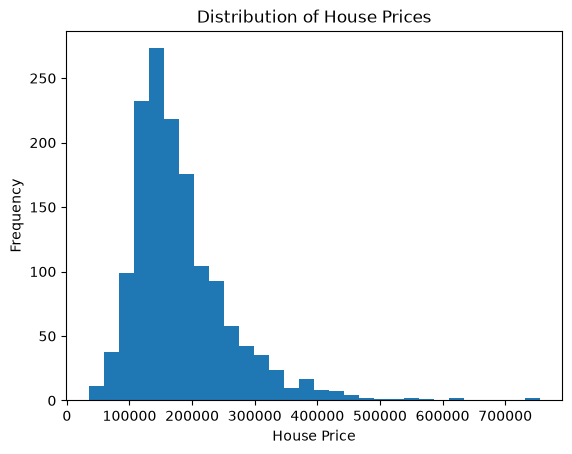

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

train_df = pd.read_csv("data/train.csv")
print(train_df.head())

X = train_df[["GrLivArea", "OverallQual"]]
Y = train_df["SalePrice"]

plt.hist(train_df["SalePrice"], bins=30)
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()


SalePrice               1.000000
OverallQual             0.790982
TotalSF                 0.782260
Neighborhood_encoded    0.738630
GrLivArea               0.708624
GarageCars              0.640409
Total_Bathrooms         0.631731
GarageArea              0.623431
TotalBsmtSF             0.613581
1stFlrSF                0.605852
FullBath                0.560664
TotRmsAbvGrd            0.533723
YearBuilt               0.522897
group_z                 0.510504
YearRemodAdd            0.507101
GarageYrBlt             0.486362
MasVnrArea              0.477493
Fireplaces              0.466929
BsmtFinSF1              0.386420
LotFrontage             0.351799
WoodDeckSF              0.324413
2ndFlrSF                0.319334
OpenPorchSF             0.315856
HalfBath                0.284108
LotArea                 0.263843
BsmtFullBath            0.227122
BsmtUnfSF               0.214479
BedroomAbvGr            0.168213
ScreenPorch             0.111447
PoolArea                0.092404
MoSold    

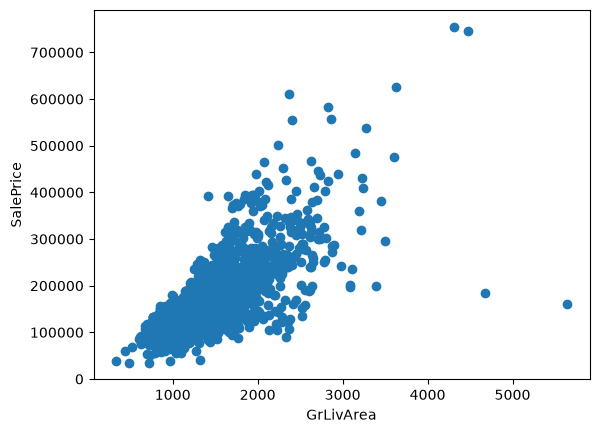

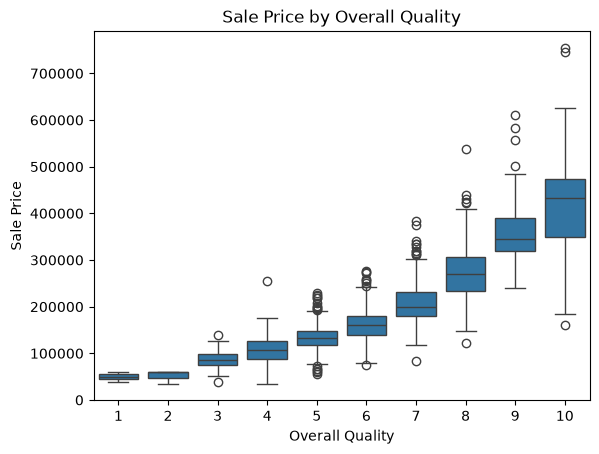

In [37]:
corr = train_df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
print(corr)

plt.scatter(train_df["GrLivArea"], Y)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

sns.boxplot(x="OverallQual", y="SalePrice", data=train_df)

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Sale Price by Overall Quality")
plt.show()


In [38]:
neigh_mean = train_df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)
neigh_map = train_df.groupby("Neighborhood")["SalePrice"].mean()

train_df["Neighborhood_encoded"] = train_df["Neighborhood"].map(neigh_map)
print(train_df[["Neighborhood_encoded", "SalePrice"]].corr())

                      Neighborhood_encoded  SalePrice
Neighborhood_encoded               1.00000    0.73863
SalePrice                          0.73863    1.00000


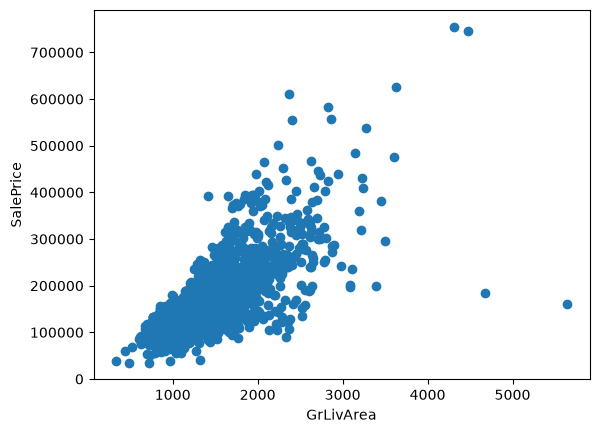

In [4]:
plt.scatter(train_df["GrLivArea"], Y)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

In [5]:
nulls = pd.DataFrame({
        "count": train_df.isnull().sum(),
        "percent": train_df.isnull().mean() * 100
    }).sort_values("percent", ascending=False)

print(nulls.head(10))

              count    percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageQual       81   5.547945
GarageFinish     81   5.547945
GarageType       81   5.547945


In [28]:
Q1 = train_df["SalePrice"].quantile(0.25)
Q3 = train_df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

print(Q1)
print(train_df["SalePrice"].mean())
print(Q3)

cols = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF"]

outliers = train_df[(train_df["SalePrice"] < Q1 - 1.5 * IQR) |
                     (train_df["SalePrice"] > Q3 + 1.5 * IQR)]

print(outliers[cols])


129975.0
180921.19589041095
214000.0
      SalePrice  OverallQual  GrLivArea  GarageCars  TotalBsmtSF
11       345000            9       2324           3         1175
53       385000            9       1842           3         1842
58       438780           10       2945           3         1410
112      383970            7       2696           3         1264
151      372402            8       1710           3         1710
...         ...          ...        ...         ...          ...
1268     381000            8       3447           3          728
1353     410000            8       3238           3         2033
1373     466500           10       2633           3         2633
1388     377500            9       1746           3         1746
1437     394617            8       1932           3         1932

[61 rows x 5 columns]


In [27]:
print(train_df.groupby("OverallQual")["SalePrice"].agg(["mean", "count"]))
print(train_df.groupby("Neighborhood")["SalePrice"].agg(["mean", "count"]))



                      mean  count
OverallQual                      
1             50150.000000      2
2             51770.333333      3
3             87473.750000     20
4            108420.655172    116
5            133523.347607    397
6            161603.034759    374
7            207716.423197    319
8            274735.535714    168
9            367513.023256     43
10           438588.388889     18
                       mean  count
Neighborhood                      
Blmngtn       194870.882353     17
Blueste       137500.000000      2
BrDale        104493.750000     16
BrkSide       124834.051724     58
ClearCr       212565.428571     28
CollgCr       197965.773333    150
Crawfor       210624.725490     51
Edwards       128219.700000    100
Gilbert       192854.506329     79
IDOTRR        100123.783784     37
MeadowV        98576.470588     17
Mitchel       156270.122449     49
NAmes         145847.080000    225
NPkVill       142694.444444      9
NWAmes        189050.068493     

In [18]:
train_df["group_z"] = (
    train_df.groupby("OverallQual")["SalePrice"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

outliers = train_df[np.abs(train_df["group_z"]) > 2.5]
print(outliers[cols])

      SalePrice  OverallQual  GrLivArea  GarageCars  TotalBsmtSF
28       207500            5       1600           1         1484
112      383970            7       2696           3         1264
114      259500            6       2320           1         1028
118      320000            7       3222           3         1673
159      320000            7       2462           2         1392
249      277000            6       2144           2         1444
313      375000            7       2036           2         2136
335      228950            5       1786           2         1499
410       60000            5       1276           1         1276
457      256000            4       1663           2         1364
462       62383            5        864           1          864
473      440000            8       1976           3         1976
495       34900            4        720           0          720
598      217500            5       1647           2         1430
607      225000          

In [22]:
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']
train_df['Total_Bathrooms'] = (train_df['FullBath'] + (0.5 * train_df['HalfBath']) + train_df['BsmtFullBath'] + (0.5 * train_df['BsmtHalfBath']))
train_df['YearsSinceRemodel'] = train_df['YrSold'] - train_df['YearRemodAdd']

print(train_df[['TotalSF', 'SalePrice']].corr())
print(train_df[['Total_Bathrooms', 'SalePrice']].corr())
print(train_df[['YearsSinceRemodel', 'SalePrice']].corr())

           TotalSF  SalePrice
TotalSF    1.00000    0.78226
SalePrice  0.78226    1.00000
                 Total_Bathrooms  SalePrice
Total_Bathrooms         1.000000   0.631731
SalePrice               0.631731   1.000000
                   YearsSinceRemodel  SalePrice
YearsSinceRemodel           1.000000  -0.509079
SalePrice                  -0.509079   1.000000


In [39]:

def calc_rmse(X, y):

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ---------- Mean encode Neighborhood ----------
    if "Neighborhood" in X_train.columns:

        # Calculate average SalePrice for each neighborhood
        train_data = X_train.copy()
        train_data["SalePrice"] = y_train

        neigh_map = train_data.groupby("Neighborhood")["SalePrice"].mean()

        # Use overall average for unseen neighborhoods
        global_mean = y_train.mean()

        # Encode train and validation sets
        X_train["Neighborhood_encoded"] = (
            X_train["Neighborhood"]
            .map(neigh_map)
            .fillna(global_mean)
        )

        X_val["Neighborhood_encoded"] = (
            X_val["Neighborhood"]
            .map(neigh_map)
            .fillna(global_mean)
        )

        # Remove original text column
        X_train = X_train.drop(columns=["Neighborhood"])
        X_val = X_val.drop(columns=["Neighborhood"])

    # ---------- Train model ----------
    model = LinearRegression()
    model.fit(X_train, y_train)

    # ---------- Evaluate ----------
    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    print(f"RMSE: {rmse:.2f}")
    # print(preds)

X = train_df[
    [
        "GrLivArea",
        "OverallQual",
        "GarageArea",
        "TotalSF",
        "Total_Bathrooms",
        "YearsSinceRemodel",
        "Neighborhood"
    ]
]

y = train_df["SalePrice"]

calc_rmse(X, y)

#X = train_df.drop("SalePrice", axis=1)
#X = pd.get_dummies(X, drop_first=True)

#y = train_df["SalePrice"]
#calc_rmse(X,Y)

RMSE: 36726.23
